In [36]:
import pandas as pd 
import numpy as np
import hashlib
import math
from csv import reader
import re
import os
import altair as alt
# import seaborn as sns
import matplotlib.pyplot as plt
# plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['ps.fonttype'] = 42
import re
pd.set_option('display.max_rows', None)
plt.style.use('seaborn-v0_8-dark-palette')


In [37]:
def hash_str(to_hash): 
    stringToHash = to_hash.encode()
    return hashlib.sha256(stringToHash).hexdigest()

In [38]:
def process_lbl(line_list, filename): 
    data_list = []
    i = 0
    name_line = ''
    
    if 'cfg' in filename: 
        setup = 'cfg'
    elif 'risc0' in filename: 
        setup = 'risc0'
    elif 'coral' in filename: 
        setup = 'coral'
    else: 
        setup = 'unknown' 

        
    if 'json' in filename: 
        app = 'json'
    elif 'toml' in filename:
        app = 'toml'
    elif filename[0]=='c': 
        app = 'c'
    else: 
        app = 'unknown'

    doc_name = (filename.split('/')[-1])[:-4]
        
    while (i < len(line_list)): 
        if i+1 < len(line_list) and '---------,---------,---------,---------' in line_list[i+1]:
            name_line = line_list[i].strip('\n')     
        elif "---------,---------,---------,---------" in line_list[i]: 
            pass
        else:   
            for line in reader([setup+','+app+','+name_line+','+line_list[i].strip()]):
                if setup=='coral':
                    to_append = [doc_name]+line[:2]+line[4:]
                else: 
                    to_append = [doc_name]+line[:2]+[line[4]]+[0,0]+[line[5]]+ line[5:] 
                if len(to_append)!= 13: 
                    print(to_append)
                data_list.append(to_append)
        i = i + 1
    return data_list        

In [39]:
def process_mem(line_list, filename): 
    data_list = []
    i = 0
    name_line = ''
    setup = ''
    app = ''
    doc = ''
    regex = ''
    batch_size = 0

    if 'cfg' in filename: 
        setup = 'cfg'
    elif 'risc0' in filename: 
        setup = 'risc0'
    elif 'coral' in filename: 
        setup = 'coral'
    else: 
        setup = 'unknown' 

    while (i < len(line_list)): 
        if 'Command being timed:' in line_list[i]:
            name_line = line_list[i]

            if 'json' in filename: 
                app = 'json'
            elif 'toml' in filename:
                app = 'toml'
            elif 'c_' in filename:
                app = 'c'
            else: 
                app = 'unknown'

            doc_size = filename.split('_')[1]

            if setup == 'coral': 
                batch_size = re.findall("-b ([0-9]*)", name_line)[0]
            else: 
                bacth_size = doc_size

        elif "Maximum resident set size" in line_list[i]: 
            mem_usage = int(line_list[i].split(':')[1].strip())/1e3
            data_list.append([filename, app, setup, doc_size, batch_size, mem_usage])
        else: 
           pass
        i = i + 1
    return data_list     

In [40]:
time_data = []
time_directory = 'tests/results/timings/scale'
 
# iterate over files in
# that directory
for filename in os.listdir(time_directory):
    filepath = os.path.join(time_directory, filename)
    if 'Data' not in filename and 'DS_Store' not in filename and os.path.isfile(filepath):
        print(filepath)
        f = open(filepath, "r")
        lbl = [x for x in f]
        f.close()
        time_data.extend(process_lbl(lbl,filename))

tests/results/timings/scale/json_4096_risc0_cfg.txt
tests/results/timings/scale/json_32768_coral.txt
tests/results/timings/scale/json_128_risc0_cfg.txt
tests/results/timings/scale/json_8192_coral.txt
tests/results/timings/scale/json_64_risc0_cfg.txt
tests/results/timings/scale/json_2048_risc0_json.txt
tests/results/timings/scale/json_16384_coral.txt
tests/results/timings/scale/json_8192_risc0_json.txt
tests/results/timings/scale/json_1024_risc0_json.txt
tests/results/timings/scale/json_256_risc0_json.txt
tests/results/timings/scale/json_16384_risc0_json.txt
tests/results/timings/scale/json_64_risc0_json.txt
tests/results/timings/scale/json_256_coral.txt
tests/results/timings/scale/json_4096_coral.txt
tests/results/timings/scale/json_512_risc0_json.txt
tests/results/timings/scale/json_2048_coral.txt
tests/results/timings/scale/json_128_risc0_json.txt
tests/results/timings/scale/json_32768_risc0_json.txt
tests/results/timings/scale/json_512_coral.txt
tests/results/timings/scale/json_128_

In [41]:
time_df = pd.DataFrame(time_data, columns = ['doc_name','setup','app','time','n_rules','tree_size','doc_len','batch_size',
                                    'test_type','component','test','val','metric'])
num_cols = ['n_rules','tree_size','batch_size','val','doc_len']
time_df[num_cols] = time_df[num_cols].apply(pd.to_numeric,errors='coerce', axis=1)

In [42]:
e2e = time_df.loc[time_df.test.str.contains('prove_e2e')].reset_index()
e2e_coral = time_df.loc[time_df.test.str.contains('prove_e2e')].groupby(['time','setup','app','doc_len','batch_size']).val.sum().reset_index()
df_e2e_avg = e2e_coral.groupby(['setup','app','batch_size','doc_len']).val.mean().reset_index()

e2e_avg_small = df_e2e_avg.iloc[df_e2e_avg.groupby('doc_len')["val"].nsmallest(1).index.get_level_values(1)].sort_values(by='doc_len')
e2e_nc = time_df.loc[(time_df.setup!='coral') & (time_df.test=='prove')]
df_e2e_nc_avg = e2e_nc.groupby(['setup','app','doc_len']).val.mean().reset_index().sort_values(by='doc_len')

In [43]:
mem_data_coral = []
mem_directory = 'tests/results/memory/scale'
 
for filename in os.listdir(mem_directory):
    filepath = os.path.join(mem_directory, filename)
    if 'Data' not in filename and 'DS_Store' not in filename and os.path.isfile(filepath):
        print(filepath)
        f = open(filepath, "r")
        lbl = [x for x in f]
        f.close()
        mem_data_coral.extend(process_mem(lbl,filename))
        
# mem_df = pd.DataFrame(mem_data_coral)
mem_df = pd.DataFrame(mem_data_coral, columns = ['filename','app','setup','doc_len','batch_size','val'])
num_cols = ['val','doc_len','batch_size']
mem_df[num_cols] = mem_df[num_cols].apply(pd.to_numeric,errors='coerce', axis=1)

tests/results/memory/scale/json_65536_risc0_json
tests/results/memory/scale/json_16384_coral
tests/results/memory/scale/json_4096_risc0_cfg
tests/results/memory/scale/json_256_risc0_cfg
tests/results/memory/scale/json_1024_coral
tests/results/memory/scale/json_4096_coral
tests/results/memory/scale/json_1024_risc0_json
tests/results/memory/scale/json_128_coral
tests/results/memory/scale/json_2048_coral
tests/results/memory/scale/json_8192_risc0_json
tests/results/memory/scale/json_4096_risc0_json
tests/results/memory/scale/json_128_risc0_json
tests/results/memory/scale/json_8192_coral
tests/results/memory/scale/json_256_coral
tests/results/memory/scale/json_32768_coral
tests/results/memory/scale/json_64_coral
tests/results/memory/scale/json_32768_risc0_json
tests/results/memory/scale/json_512_risc0_json
tests/results/memory/scale/json_16384_risc0_json
tests/results/memory/scale/json_256_risc0_json
tests/results/memory/scale/json_512_coral
tests/results/memory/scale/json_1024_risc0_cfg
t

In [44]:
mem_df_avg = mem_df.groupby(['filename','setup','app','doc_len','batch_size']).val.mean().reset_index()
mem_coral = mem_df_avg.loc[mem_df_avg.setup.str.contains("coral")]

In [45]:
best_prove_time_combo = list(zip(e2e_avg_small.doc_len, e2e_avg_small.batch_size))
tuples_in_df = pd.MultiIndex.from_frame(mem_coral[["doc_len","batch_size"]])
mem_coral_small = mem_coral[tuples_in_df.isin(best_prove_time_combo)].sort_values(by=['doc_len'])

In [46]:
mem_nc = mem_df_avg.loc[mem_df_avg.setup != "coral"].sort_values(by=['doc_len'])

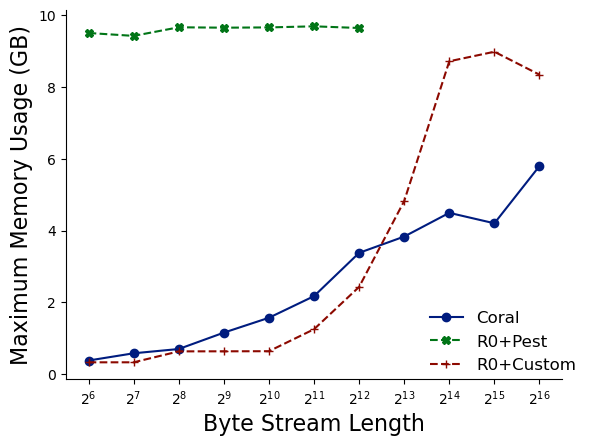

In [47]:
# Create a figure and an axes
# plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots()
ax.set_xscale('log', base = 2)
# ax.set_yscale('log')

# Group data by the 'line_id' column
# for line_name, group_data in df.groupby('line_id'):
#     Plot x_value vs y_value for each group
ax.plot(mem_coral_small.doc_len, mem_coral_small.val/1e3, marker='o')


i = 0; 
for line_name, group_data in mem_nc.groupby('setup'):
    if i == 0: 
        ax.plot(group_data.doc_len, group_data.val/1e3, linestyle='dashed', marker='X')
        i = i + 1
    else:
        ax.plot(group_data.doc_len, group_data.val/1e3, linestyle='dashed', marker='+')

# Add labels and title
ax.set_xlabel("Byte Stream Length", fontsize=16)
ax.set_ylabel("Maximum Memory Usage (GB)", fontsize=16)
ax.set_xticks([2**i for i in range(6,17)])
ax.set_facecolor('white')
# ax.set_title("Maximum Memory Usage")

# Add a legend to distinguish lines
# ax.legend()
ax.legend(['Coral', 'R0+Pest', 'R0+Custom'], loc=(.72,0), fontsize=12, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Display the plot
plt.savefig("compmem.pdf", format="pdf",bbox_inches='tight' )
plt.show()

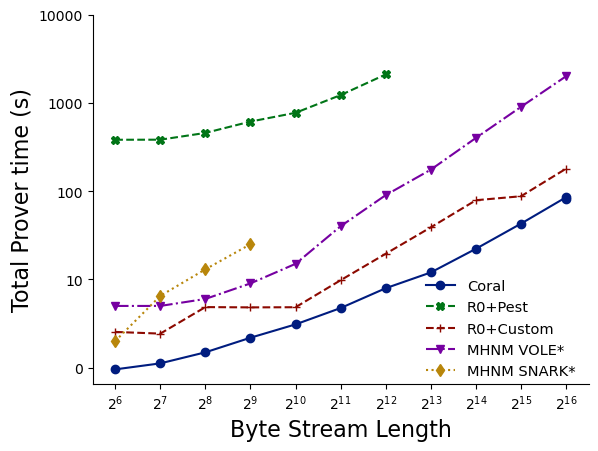

In [48]:
# Create a figure and an axes
fig, ax = plt.subplots()
# plt.rcParams.update({'font.size': 15})
ax.set_xscale('log', base = 2)
ax.set_yscale('log')

# Group data by the 'line_id' column
# for line_name, group_data in df.groupby('line_id'):
    # Plot x_value vs y_value for each group
ax.plot(e2e_avg_small.doc_len, e2e_avg_small.val/1e6, marker='o')

i = 0
for line_name, group_data in df_e2e_nc_avg.groupby('setup'):
    if i == 0: 
        m = 'X'
        i = i + 1
    else: 
        m = '+'
    ax.plot(group_data.doc_len, group_data.val/1e6, linestyle='dashed', marker=m)

ax.plot([2**i for i in range(6,17)],[5,5,6,9,15,40,90,175,400,900,2000], linestyle='dashdot',marker='v')
ax.plot([2**i for i in range(6,10)],[2,6.5,13,25],linestyle='dotted',marker="d")

# Add labels and title
ax.set_xlabel("Byte Stream Length",fontsize=16)
ax.set_ylabel("Total Prover time (s)",fontsize=16)
ax.set_xticks([2**i for i in range(6,17)])
ax.set_yticks([1,10,100])
plt.yticks([1,10,100,1000,10000], ['0','10','100','1000','10000'])
ax.set_facecolor('white')
# ax.set_title("Prover time as a function of Document Size")
plt.minorticks_off()

# Add a legend to distinguish lines
ax.legend(['Coral', 'R0+Pest', 'R0+Custom','MHNM VOLE*', 'MHNM SNARK*'], prop={'size': 10.5}, loc=(.66,.00), frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#Change to be shapes, and change colors, maybe fix log scale idk 
# Display the plot
plt.savefig("comptime.pdf", format="pdf",bbox_inches='tight')
plt.show()

In [49]:
app_data = []
app_directory = 'tests/results/timings/apps'
 
# iterate over files in
# that directory
for filename in os.listdir(app_directory):
    filepath = os.path.join(app_directory, filename)
    if 'Data' not in filename and 'DS_Store' not in filename and os.path.isfile(filepath):
        print(filepath)
        f = open(filepath, "r")
        lbl = [x for x in f]
        f.close()
        app_data.extend(process_lbl(lbl,filename))

tests/results/timings/apps/c_c1_risc0_c.txt
tests/results/timings/apps/json_jwt_coral.txt
tests/results/timings/apps/c_c3_coral.txt
tests/results/timings/apps/json_bank_citi_risc0_cfg.txt
tests/results/timings/apps/json_hibp_small_coral.txt
tests/results/timings/apps/json_bank_plaid_coral.txt
tests/results/timings/apps/c_llvm_risc0_c.txt
tests/results/timings/apps/json_bank_plaid_risc0_json.txt
tests/results/timings/apps/c_llvm_risc0_cfg.txt
tests/results/timings/apps/toml_t1_coral.txt
tests/results/timings/apps/json_bank_citi_coral.txt
tests/results/timings/apps/toml_t2_risc0_cfg.txt
tests/results/timings/apps/c_c2_risc0_cfg.txt
tests/results/timings/apps/c_c1_risc0_cfg.txt
tests/results/timings/apps/c_c2_coral.txt
tests/results/timings/apps/json_bank_citi_risc0_json.txt
tests/results/timings/apps/c_llvm_coral.txt
tests/results/timings/apps/c_c2_risc0_c.txt
tests/results/timings/apps/json_hibp_small_risc0_json.txt
tests/results/timings/apps/toml_t1_risc0_cfg.txt
tests/results/timings/

In [50]:
mem_app_data_coral = []
mem_app_directory = 'tests/results/memory/apps'
 
for filename in os.listdir(mem_app_directory):
    filepath = os.path.join(mem_app_directory, filename)
    if 'Data' not in filename and 'DS_Store' not in filename and os.path.isfile(filepath):
        print(filepath)
        f = open(filepath, "r")
        lbl = [x for x in f]
        f.close()
        mem_app_data_coral.extend(process_mem(lbl,filename))
        
# mem_df = pd.DataFrame(mem_data_coral)
mem_app_df = pd.DataFrame(mem_app_data_coral, columns = ['filename','app','setup','doc_name','batch_size','val'])
num_cols = ['val','batch_size']
mem_app_df[num_cols] = mem_app_df[num_cols].apply(pd.to_numeric,errors='coerce', axis=1)

tests/results/memory/apps/c_c1_risc0_c
tests/results/memory/apps/json_jwt_risc0_json
tests/results/memory/apps/json_hibp_small_risc0_json
tests/results/memory/apps/c_c2_risc0_cfg
tests/results/memory/apps/json_bank_citi_risc0_json
tests/results/memory/apps/c_llvm_risc0_c
tests/results/memory/apps/toml_t2_risc0_toml
tests/results/memory/apps/json_hibp_risc0_json
tests/results/memory/apps/json_jwt_coral
tests/results/memory/apps/json_bank_citi_risc0_cfg
tests/results/memory/apps/json_hibp_risc0_cfg
tests/results/memory/apps/json_dk_risc0_json
tests/results/memory/apps/json_hibp_small_risc0_cfg
tests/results/memory/apps/json_dmv_veratad_coral
tests/results/memory/apps/toml_t1_risc0_cfg
tests/results/memory/apps/c_c2_risc0_c
tests/results/memory/apps/json_bank_plaid_risc0_cfg
tests/results/memory/apps/c_c3_risc0_c
tests/results/memory/apps/json_bank_citi_coral
tests/results/memory/apps/json_jwt_risc0_cfg
tests/results/memory/apps/json_bank_plaid_risc0_json
tests/results/memory/apps/json_dk

In [51]:
mem_app_df_avg = mem_app_df.groupby(['filename','setup','app','batch_size']).val.mean().reset_index()
mem_app_coral = mem_app_df_avg.loc[mem_app_df_avg.setup.str.contains("coral")]

In [52]:
app_df = pd.DataFrame(app_data, columns = ['doc_name','setup','app','time','n_rules','tree_size','doc_len','batch_size',
                                    'test_type','component','test','val','metric'])
num_cols = ['n_rules','tree_size','batch_size','val','doc_len']
app_df[num_cols] = app_df[num_cols].apply(pd.to_numeric,errors='coerce', axis=1)

coral_app_df = app_df.loc[app_df.setup=='coral']


e2e_coral_app = coral_app_df.loc[coral_app_df.test.str.contains('prove_e2e')].groupby(['time',
                                                'app','doc_name','batch_size']).val.sum().reset_index()
df_e2e_avg_app = e2e_coral_app.groupby(['doc_name','app','batch_size']).val.mean().reset_index()
e2e_avg_small_app = df_e2e_avg_app.iloc[
    df_e2e_avg_app.groupby('doc_name')["val"].nsmallest(1).index.get_level_values(1)].sort_values(by='doc_name')

best_prove_time_combo_app = list(zip(e2e_avg_small_app.doc_name, e2e_avg_small_app.batch_size))
tuples_in_df_app = pd.MultiIndex.from_frame(coral_app_df[["doc_name","batch_size"]])
coral_df_app_filter = coral_app_df[tuples_in_df_app.isin(best_prove_time_combo_app)]

In [84]:
cfg = app_df.loc[(app_df.setup=='cfg')&(app_df.test=='prove')]
risc0 = app_df.loc[(app_df.setup=='risc0')&(app_df.test=='prove')]
risc0_avg = risc0.groupby(['doc_name','app','test']).val.mean().reset_index()
cfg_avg = cfg.groupby(['doc_name','app','test']).val.mean().reset_index()

In [85]:
tuples_in_df_app_mem = pd.MultiIndex.from_frame(mem_app_coral[["filename","batch_size"]])
to_latex = mem_app_coral[tuples_in_df_app_mem.isin(best_prove_time_combo_app)]
to_latex.rename(columns = {"filename":"doc_name"},inplace=True)

/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_79137/3423320731.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_latex.rename(columns = {"filename":"doc_name"},inplace=True)


In [86]:
constraints = coral_df_app_filter.loc[coral_df_app_filter.metric=='constraints'].groupby(['doc_name']).val.mean().to_frame().reset_index()

In [87]:
to_latex = to_latex.merge(constraints, on='doc_name', suffixes = ['_mem','_cons'])

In [88]:
proof_size = (coral_df_app_filter.loc[coral_df_app_filter.metric=='bytes'].groupby(['doc_name']).val.mean()/1e3).to_frame().reset_index()
to_latex = to_latex.merge(proof_size, on='doc_name')

In [89]:
verify = (coral_df_app_filter.loc[(coral_df_app_filter.component=='V') & 
    (coral_df_app_filter.test.isin(["full_verify"]))].groupby(['doc_name',
                                                                    'time']).val.sum().reset_index().groupby(['doc_name']).val.mean()/1e6).to_frame().reset_index()
to_latex = to_latex.merge(verify, on='doc_name',suffixes = ['_size','_verify'])

In [90]:
cg = coral_df_app_filter.loc[(
    (coral_df_app_filter.component=='G') | 
    (coral_df_app_filter.test=='witness_synthesis_0') |  
    (coral_df_app_filter.test.str.contains('nova_pp_gen'))
    )]
setup = (cg.groupby(['doc_name','test']).val.mean().reset_index().groupby(['doc_name']).val.sum()/1e6).to_frame().reset_index()
to_latex = to_latex.merge(setup, on='doc_name')

In [91]:
solve = (coral_df_app_filter.loc[coral_df_app_filter.test=='e2e_solving'].groupby(['doc_name']).val.mean()/1e6).to_frame().reset_index()
to_latex = to_latex.merge(solve, on='doc_name',suffixes = ['_setup','_solve'])

In [92]:
prove = (coral_df_app_filter.loc[coral_df_app_filter.test=='prove_e2e'].groupby(['doc_name']).val.mean()/1e6).to_frame().reset_index()
to_latex = to_latex.merge(prove, on='doc_name')

In [93]:
extra_data = coral_df_app_filter[['doc_name','tree_size','doc_len']].drop_duplicates()

In [94]:
to_latex = to_latex.merge(extra_data, on='doc_name')
to_latex.drop(columns=['setup'], inplace=True)
to_latex = to_latex[['app','doc_name','doc_len','tree_size','val_cons',
                     'batch_size','val_setup','val_solve','val','val_verify','val_size','val_mem']]
to_latex.val_mem = to_latex.val_mem/1e3

In [100]:
to_latex.to_latex(index=False)
#                  formatters={"name": str.upper},
 #                 float_format="{:.1f}".format,

'\\begin{tabular}{llrrrrrrrrrr}\n\\toprule\napp & doc_name & doc_len & tree_size & val_cons & batch_size & val_setup & val_solve & val & val_verify & val_size & val_mem \\\\\n\\midrule\nc & c_c1_coral & 56 & 241 & 89382.000000 & 87.000000 & 1.960505 & 0.122750 & 1.127995 & 0.032461 & 16.650000 & 0.471921 \\\\\nc & c_c2_coral & 237 & 1173 & 141229.000000 & 155.000000 & 2.215609 & 0.146309 & 1.907398 & 0.038071 & 17.194000 & 0.769651 \\\\\nc & c_c3_coral & 399 & 2027 & 211320.000000 & 242.000000 & 2.470497 & 0.171739 & 2.398942 & 0.041228 & 17.194000 & 0.957812 \\\\\nc & c_llvm_coral & 1431 & 6652 & 455274.000000 & 543.000000 & 3.690541 & 0.304327 & 5.191545 & 0.065622 & 18.282000 & 2.638236 \\\\\njson & json_bank_citi_coral & 2336 & 9503 & 413129.000000 & 611.000000 & 3.394620 & 0.403534 & 5.517906 & 0.054134 & 17.738000 & 1.945449 \\\\\njson & json_bank_plaid_coral & 312 & 1348 & 105668.000000 & 141.000000 & 2.112933 & 0.156320 & 1.961059 & 0.035431 & 16.650000 & 0.522221 \\\\\njson & 

,app,doc_name,doc_len,tree_size,val_cons,batch_size,val_setup,val_solve,val,val_verify,val_size,val_mem
0,c,c_c1_coral,56,241,89382.0,87.0,1.960505,0.122750,1.127995,0.032461,16.650,0.471921
1,c,c_c2_coral,237,1173,141229.0,155.0,2.215609,0.146309,1.907398,0.038071,17.194,0.769651
2,c,c_c3_coral,399,2027,211320.0,242.0,2.470497,0.171739,2.398942,0.041228,17.194,0.957812
3,c,c_llvm_coral,1431,6652,455274.0,543.0,3.690541,0.304327,5.191545,0.065622,18.282,2.638236
4,json,json_bank_citi_coral,2336,9503,413129.0,611.0,3.394620,0.403534,5.517906,0.054134,17.738,1.945449
5,json,json_bank_plaid_coral,312,1348,105668.0,141.0,2.112933,0.156320,1.961059,0.035431,16.650,0.522221
6,json,json_dk_coral,1547,7263,431620.0,641.0,3.453535,0.317300,5.050338,0.052953,17.738,1.939901
7,json,json_dmv_veratad_coral,748,2594,212606.0,305.0,2.545315,0.179426,2.518188,0.041659,17.194,0.976799
8,json,json_jwt_coral,384,1777,145281.0,201.0,2.237849,0.158430,2.024694,0.038419,17.194,0.785344
9,toml,toml_t1_coral,379,2050,200766.0,267.0,2.503161,0.179445,2.359135,0.041610,17.194,0.948377


In [66]:
def change_app_name_json(filename): 
    if "citi" in filename: 
        return "CitiBank"
    if "plaid" in filename: 
        return "Plaid"
    if "dk" in filename: 
        return "Sports"
    if "dmv" in filename: 
        return "Age"
    if "hibp_small" in filename: 
        return "HIBP"
    if "hibp" in filename: 
        return "X"
    if "jwt" in filename: 
        return "JWT"
    else: 
        return "Unknown"
        
def change_app_name(filename): 
    if "c1" in filename: 
        return "C1"
    if "c2" in filename: 
        return "C2"
    if "c3" in filename: 
        return "C3"
    if "llvm" in filename: 
        return "LLVM"
    if "toml_small" in filename: 
        return "T1"
    if "toml_coral" in filename: 
        return "T2"
    if "ark" in filename: 
        return "T3"
    else: 
        return "Unknown"
  
def change_test_name(test): 
    if test=="prove": 
        return "Baseline"
    if test=="Solving":
        return "Solving"
    if test=="prove_e2e":
        return "Prove"
    if test=="solving":
        return "Solving"
    else: 
        return "Unknown"

In [51]:
pt_coral = coral_df_app_filter.loc[coral_df_app_filter.test.str.contains('prove_e2e')].groupby([
                                                'app','doc_name','batch_size','test']).val.mean().reset_index()
pt_coral_solving_int = coral_df_app_filter.loc[coral_df_app_filter.test.str.contains('e2e_solving')].groupby([
                                                'app','doc_name','batch_size','time']).val.sum().reset_index()
pt_coral_solving = pt_coral_solving_int.groupby([
                                                'app','doc_name','batch_size']).val.mean().reset_index()
pt_coral_solving['test']='Solving'

pt_coral = pd.concat([pt_coral, pt_coral_solving])
json_coral = pt_coral.loc[pt_coral.app=='json']
json_cfg = cfg_avg.loc[cfg_avg.app=='json']
json_risc0 = risc0_avg.loc[risc0_avg.app=='json']

In [52]:
json_coral['Name'] = json_coral.doc_name.apply(lambda x: change_app_name_json(x))
json_cfg['Name'] = json_cfg.doc_name.apply(lambda x: change_app_name_json(x))
json_risc0['Name'] = json_risc0.doc_name.apply(lambda x: change_app_name_json(x))

json_coral['Component'] = json_coral.test.apply(lambda x: change_test_name(x))
json_cfg['Component'] = json_cfg.test.apply(lambda x: change_test_name(x))
json_risc0['Component'] = json_risc0.test.apply(lambda x: change_test_name(x))

/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_82723/2390281631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  json_coral['Name'] = json_coral.doc_name.apply(lambda x: change_app_name_json(x))
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_82723/2390281631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  json_cfg['Name'] = json_cfg.doc_name.apply(lambda x: change_app_name_json(x))
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_82723/2390281631.py:3: SettingWithCop

In [62]:
def prep_df(df, name):
    # df = df.stack().reset_index()
    df.columns = ['val', 'Name', 'Component']
    df.val = df.val/1e6
    df['Setup'] = name
    return df


In [63]:
df1 = prep_df(json_coral[['val', 'Name', 'Component']], 'Coral')
df2 = prep_df(json_cfg[['val', 'Name', 'Component']], 'R0+Pest')
df3 = prep_df(json_risc0[['val', 'Name', 'Component']], 'R0+Custom')

df = pd.concat([df1, df2, df3])

/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_75569/2225007191.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.val = df.val/1e6
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_75569/2225007191.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Setup'] = name
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_75569/2225007191.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [64]:
df = df.loc[df.Name!='X']
custom = {'Age':0, "CitiBank":1, "Plaid":2, "Sports":3, "HIBP":4, "JWT":5}
df = df.sort_values(by=['Name'],key=lambda x: x.map(custom))

In [66]:
 # chart = 
c1 = alt.Chart(df).mark_bar(clip=True).encode(

    # tell Altair which field to group columns on
    x=alt.X('Setup:N', title=None),

    # tell Altair which field to use as Y values and how to calculate
    y=alt.Y('sum(val):Q',
        axis=alt.Axis(
            grid=False,
            title="Total Prover Time")).scale(domain=(0,60)),

    # tell Altair which field to use to use as the set of columns to be  represented in each group
    column=alt.Column('Name:N', title=None,header=alt.Header(titleOrient='bottom', labelOrient='bottom',labelFontSize=15)).sort(['sadf']),
    order=alt.Order(
      # Sort the segments of the bars by this field
      'val',
      sort='descending'
    ),
    # tell Altair which field to use for color segmentation 
    color=alt.Color('Component:N',
            scale=alt.Scale(
                # make it look pretty with an enjoyable color pallet
                range=['#3d85c6', '#FF7F50','#b43709',"#d74814"],
            ),
        ))\
    .configure_view(
        # remove grid lines around column clusters
        strokeOpacity=0    
    ).configure_axis(
    labelFontSize=15,
    titleFontSize=15
).configure_legend(
     titleFontSize=15,
    labelFontSize=15,
    padding = 1,
    fillColor='white',
    orient = 'none', 
    legendX = 10,
    legendY = 40,
).properties(
    width=100,
    height=300
)
# c1.save("json_comp.pdf")

In [67]:
c1

alt.Chart(...)

In [65]:
# pt_coral = coral_df_filter.loc[coral_df_filter.test.str.contains('e2e|solving|sample')].groupby([
#                                                 'app','doc_name','batch_size','test']).val.mean().reset_index()
app_coral = pt_coral.loc[pt_coral.app!='json']
app_cfg = cfg_avg.loc[cfg_avg.app!='json']
app_risc0 = risc0_avg.loc[risc0_avg.app!='json']

In [66]:
app_coral['Name'] = app_coral.doc_name.apply(lambda x: change_app_name(x))
app_cfg['Name'] = app_cfg.doc_name.apply(lambda x: change_app_name(x))
app_risc0['Name'] = app_risc0.doc_name.apply(lambda x: change_app_name(x))

app_coral['Component'] = app_coral.test.apply(lambda x: change_test_name(x))
app_cfg['Component'] = app_cfg.test.apply(lambda x: change_test_name(x))
app_risc0['Component'] = app_risc0.test.apply(lambda x: change_test_name(x))

/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_63919/2585962810.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_coral['Name'] = app_coral.doc_name.apply(lambda x: change_app_name(x))
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_63919/2585962810.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_cfg['Name'] = app_cfg.doc_name.apply(lambda x: change_app_name(x))
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_63919/2585962810.py:3: SettingWithCopyWarning: 
A v

In [67]:
df1 = prep_df(app_coral[['val', 'Name', 'Component']], 'Coral')
df2 = prep_df(app_cfg[['val', 'Name', 'Component']], 'R0+Pest')
df3 = prep_df(app_risc0[['val', 'Name', 'Component']], 'R0+Custom')

df = pd.concat([df1, df2, df3])
df = df.sort_values(by='Name', ascending = True)

/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_63919/2225007191.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.val = df.val/1e6
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_63919/2225007191.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Setup'] = name
/var/folders/y0/m5s5d3c1733_n9v6lmsxn3v00000gn/T/ipykernel_63919/2225007191.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [68]:
# chart = 
alt.Chart(df).mark_bar(clip=True).encode(

    # tell Altair which field to group columns on
    x=alt.X('Setup:N', title=None),

    # tell Altair which field to use as Y values and how to calculate
    y=alt.Y('sum(val):Q',
        axis=alt.Axis(
            grid=False,
            title="Total Prover Time")).scale(domain=(0,100)),

    # tell Altair which field to use to use as the set of columns to be  represented in each group
    column=alt.Column('Name:N', title=None, sort=['C2','C1','C3','LLVM', 'T1','T2','T3'],
                     header=alt.Header(titleFontSize=200, titleOrient='bottom', labelOrient='bottom',labelFontSize=15)),
    order=alt.Order(
      # Sort the segments of the bars by this field
      'val',
      sort='descending'
    ),
    # tell Altair which field to use for color segmentation 
    color=alt.Color('Component:N',
            scale=alt.Scale(
                # make it look pretty with an enjoyable color pallet
                range=['#3d85c6', '#FF7F50','#b43709',"#d74814"],
            ),
        ))\
    .configure_view(
        # remove grid lines around column clusters
        strokeOpacity=0    
    ).configure_axis(
    labelFontSize=15,
    titleFontSize=15
).configure_legend(
     titleFontSize=15,
    labelFontSize=15,
            fillColor='white',
    orient = 'none', 
    legendX = 10,
    legendY = 40,
).properties(
    width=100,
    height=300
)
# chart.save("app_comp.pdf")

alt.Chart(...)